In [1]:
from pathlib import Path
import csv
from typing import List, Sequence

import torch

from ppo_xarm7 import Agent

CSV_PATH = Path("rollout_debug_log_expanded.csv")
CHECKPOINT_PATH = Path("runs/MyJointHold-v0__ppo_xarm7__1__1759051124/final_ckpt.pt")
DETERMINISTIC_POLICY = True
CONVERT_GRIPPER = True

JOINT_POSITION_LOW = torch.tensor(
    [
        -6.283185307179586,
        -2.059,
        -6.283185307179586,
        -0.19198,
        -6.283185307179586,
        -1.69297,
        -6.283185307179586,
        0.05,
    ],
    dtype=torch.float32,
)
JOINT_POSITION_HIGH = torch.tensor(
    [
        6.283185307179586,
        2.0944,
        6.283185307179586,
        3.927,
        6.283185307179586,
        3.141592653589793,
        6.283185307179586,
        0.84,
    ],
    dtype=torch.float32,
)
_DELTA_PHYSICAL_LOW = torch.full((8,), -0.1, dtype=torch.float32)
_DELTA_PHYSICAL_HIGH = torch.full((8,), 0.1, dtype=torch.float32)


class _DummySpace:
    def __init__(self, shape: Sequence[int]):
        self.shape = tuple(shape)


class _DummyEnv:
    def __init__(self, obs_shape: Sequence[int], action_shape: Sequence[int]):
        self.single_observation_space = _DummySpace(obs_shape)
        self.single_action_space = _DummySpace(action_shape)


def gripper_q_maniskill_to_robomanip(q_maniskill: torch.Tensor) -> torch.Tensor:
    return q_maniskill * (-1000.0) + 840.0


def _infer_indexed_columns(fieldnames: Sequence[str], prefix: str) -> List[str]:
    indexed = []
    for name in fieldnames:
        if name.startswith(prefix):
            try:
                idx = int(name[len(prefix) :])
            except ValueError:
                continue
            indexed.append((idx, name))
    indexed.sort(key=lambda item: item[0])
    return [name for _, name in indexed]


with CSV_PATH.open("r", newline="") as f:
    reader = csv.DictReader(f)
    if reader.fieldnames is None:
        raise ValueError("CSV file is empty or missing a header row")

    obs_columns = _infer_indexed_columns(reader.fieldnames, "obs_")
    action_columns = _infer_indexed_columns(reader.fieldnames, "direct_joint_command_")
    if not obs_columns:
        raise ValueError("No observation columns found (expected obs_0, obs_1, ...)")

    rows = []
    for idx, row in enumerate(reader):
        step_idx = int(row.get("step_idx", idx))
        obs = [float(row[col]) for col in obs_columns]
        ref = [float(row[col]) for col in action_columns] if action_columns else None
        rows.append((step_idx, obs, ref))

if not rows:
    raise ValueError("No rows parsed from rollout_debug_log_expanded.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
action_dim = int(state_dict["actor_logstd"].shape[-1])

dummy_env = _DummyEnv((len(obs_columns),), (action_dim,))
agent = Agent(dummy_env).to(device)
agent.load_state_dict(state_dict)
agent.eval()

normalized_low = torch.full((action_dim,), -1.0, device=device)
normalized_high = torch.full((action_dim,), 1.0, device=device)
physical_low = _DELTA_PHYSICAL_LOW.to(device)
physical_high = _DELTA_PHYSICAL_HIGH.to(device)
joint_position_low = JOINT_POSITION_LOW.to(device)
joint_position_high = JOINT_POSITION_HIGH.to(device)

step_indices: List[int] = []
obs_joint_positions: List[List[float]] = []
policy_joint_commands: List[List[float]] = []
logged_joint_commands: List[List[float]] | None = [] if action_columns else None

for step_idx, obs, ref in rows:
    step_indices.append(step_idx)
    obs_joint_positions.append(obs[:action_dim])

    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        action = agent.get_action(obs_tensor, deterministic=DETERMINISTIC_POLICY)
    clipped_action = torch.clamp(action, normalized_low, normalized_high)

    scale = (clipped_action - normalized_low) / (normalized_high - normalized_low)
    denormalized_delta = physical_low + scale * (physical_high - physical_low)
    current_joint_pos = obs_tensor[..., :action_dim]
    direct_joint_command = current_joint_pos + denormalized_delta
    direct_joint_command = torch.max(
        torch.min(direct_joint_command, joint_position_high), joint_position_low
    )
    if CONVERT_GRIPPER:
        direct_joint_command = direct_joint_command.clone()
        direct_joint_command[..., -1] = gripper_q_maniskill_to_robomanip(
            direct_joint_command[..., -1]
        )

    policy_joint_commands.append(direct_joint_command.squeeze(0).cpu().tolist())
    if logged_joint_commands is not None and ref is not None:
        logged_joint_commands.append(ref)

policy_joint_commands = torch.tensor(policy_joint_commands, dtype=torch.float32)
obs_joint_positions = torch.tensor(obs_joint_positions, dtype=torch.float32)
step_indices = torch.tensor(step_indices, dtype=torch.int64)
if logged_joint_commands:
    logged_joint_commands = torch.tensor(logged_joint_commands, dtype=torch.float32)
else:
    logged_joint_commands = None

if isinstance(logged_joint_commands, torch.Tensor):
    diff = (policy_joint_commands - logged_joint_commands).abs()
    print(
        f"command abs diff max={diff.max().item():.6e}, mean={diff.mean().item():.6e}"
    )
else:
    print("CSV did not contain direct_joint_command_* columns; skipping diff report.")


/home/kotaro/miniconda3/envs/maniskill/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/kotaro/miniconda3/envs/maniskill/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


command abs diff max=0.000000e+00, mean=0.000000e+00


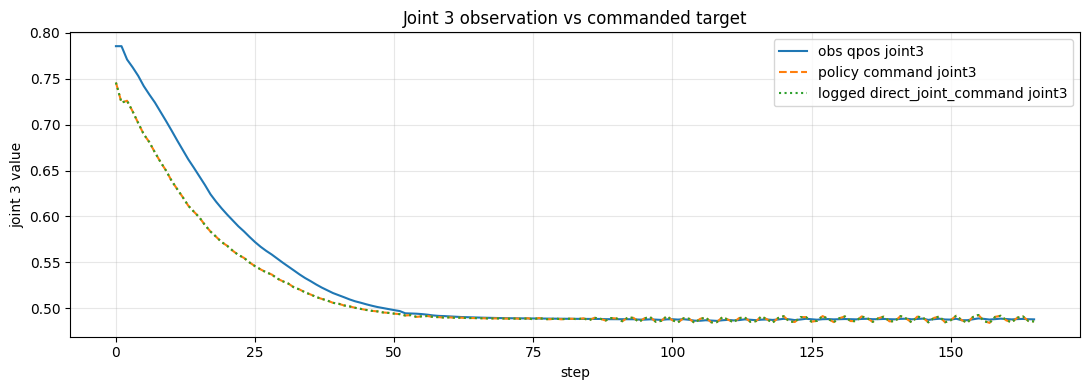

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

joint_index = 3  # joint3 (0-based index)

steps = step_indices.cpu().numpy()
obs_series = obs_joint_positions[:, joint_index].cpu().numpy()
policy_series = policy_joint_commands[:, joint_index].cpu().numpy()

plt.figure(figsize=(11, 4))
plt.plot(steps, obs_series, label="obs qpos joint3")
plt.plot(steps, policy_series, label="policy command joint3", linestyle="--")

if isinstance(logged_joint_commands, torch.Tensor):
    logged_series = logged_joint_commands[:, joint_index].cpu().numpy()
    plt.plot(steps, logged_series, label="logged direct_joint_command joint3", linestyle=":")

plt.xlabel("step")
plt.ylabel("joint 3 value")
plt.title("Joint 3 observation vs commanded target")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
